# Mandatory: Supervised Learning II
# Abalone Age Training Models
This notebook focuses on training and evaluating various supervised learning models to predict the age of abalones based on the preprocessed dataset. We will explore different regression algorithms, tune hyperparameters, and assess model performance using appropriate metrics.

### Goal on this notebook
- Train multiple regression models (e.g., Linear Regression, Decision Trees, Random Forests, Gradient Boosting, etc.) on the processed abalone dataset.
- Perform hyperparameter tuning using techniques like Grid Search or Random Search with cross-validation.
- Evaluate model performance using metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared.
- Compare model results based on the different datasets created in the previous notebook (full PCA dataset vs. reduced dataset vs. original dataset).

For this test the data will only be split into training and test sets, as cross-validation will be used during hyperparameter tuning.

### Package Imports and Data Loading
We start by importing necessary packages and loading both the original and processed datasets.

In [151]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import make_scorer
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, get_scorer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import KFold


Since our target variable "rings" is continuous, we will not perform stratified splitting. This is because stratified splitting is typically used for classification tasks to ensure that each class is represented proportionally in both training and test sets. In regression tasks, the target variable is continuous, making stratification less straightforward and often unnecessary. Instead, we will use random splitting to create our training and test sets.  
Also, stratfication won't work here since there are too many unique values in the "rings" column.

In [119]:
def tts(df, target_col, test_size=0.2, random_state=None):
    # 1. Split into train and test
    train, test = train_test_split(
        df,
        test_size=test_size,
        random_state=random_state,
        stratify=None  # No stratification for regression tasks
    )
    # 2. Separate features (X) and labels (y)
    X_train, y_train = train.drop(columns=[target_col]), train[target_col]
    X_test, y_test   = test.drop(columns=[target_col]), test[target_col]
    # 3. print shapes of the splits
    print(f"Train set shape:\n {X_train.shape}, {y_train.shape}")
    print(f"Test set shape:\n {X_test.shape}, {y_test.shape}")
    # 4. return the splits
    return X_train, X_test, y_train, y_test

To make the original dataset compatible with the intended regression models, we will drop the non-numeric column "sex" from the original dataset.  
PCA and reduced datasets are already numeric.

In [120]:
abalone_df_org = pd.read_csv('../data/abalone.csv', sep=',', names=["sex", "length", "diameter", "height", "whole_weight", "shucked_weight", "viscera_weight", "shell_weight", "rings"])
abalone_df_org = abalone_df_org.drop("sex", axis=1) # Drop non-numeric column for simplicity
abalone_df_pca = pd.read_csv('../data/abalone_processed_full.csv', sep=',')
abalone_df_reduced = pd.read_csv('../data/abalone_processed_reduced.csv', sep=',')

In [121]:
print("Original DataFrame:")
X_train_org, X_test_org, y_train_org, y_test_org = tts(abalone_df_org, target_col="rings")
print("\nPCA Processed DataFrame:")
X_train_pca, X_test_pca, y_train_pca, y_test_pca = tts(abalone_df_pca, target_col="rings")
print("\nReduced Features DataFrame:")
X_train_red, X_test_red, y_train_red, y_test_red = tts(abalone_df_reduced, target_col="rings")

Original DataFrame:
Train set shape:
 (3341, 7), (3341,)
Test set shape:
 (836, 7), (836,)

PCA Processed DataFrame:
Train set shape:
 (3341, 4), (3341,)
Test set shape:
 (836, 4), (836,)

Reduced Features DataFrame:
Train set shape:
 (3341, 3), (3341,)
Test set shape:
 (836, 3), (836,)


### Build & Train Baselines
For this round, we'll try to build and train some baseline models on the different datasets.  
This will be done with a for loop that iterates through different models with minimal tuning of hyperparameters.

In [122]:
def baseline_model_training(X_train, y_train, X_test, y_test):
    models = {
        "LinearRegression": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "Lasso": Lasso(alpha=0.001),
        "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
        "GradientBoosting": GradientBoostingRegressor(random_state=42)
    }

    results = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        results[name] = {
            "RMSE": root_mean_squared_error(y_test, y_pred),
            "R2": r2_score(y_test, y_pred)
        }

    print(pd.DataFrame(results).T)
    

In [123]:
baseline_model_training(X_train_org, y_train_org, X_test_org, y_test_org)

                      RMSE        R2
LinearRegression  2.374837  0.431474
Ridge             2.269258  0.480900
Lasso             2.336327  0.449762
RandomForest      2.181912  0.520093
GradientBoosting  2.128613  0.543252


In [124]:
baseline_model_training(X_train_pca, y_train_pca, X_test_pca, y_test_pca)

                      RMSE        R2
LinearRegression  2.462648  0.431012
Ridge             2.462750  0.430965
Lasso             2.463015  0.430843
RandomForest      2.393684  0.462434
GradientBoosting  2.321478  0.494376


In [125]:
baseline_model_training(X_train_red, y_train_red, X_test_red, y_test_red)

                      RMSE        R2
LinearRegression  2.696284  0.319957
Ridge             2.696288  0.319955
Lasso             2.696385  0.319906
RandomForest      2.540808  0.396122
GradientBoosting  2.469816  0.429397


### Baseline Evaluation
So in the baseline models we got the following results:
| Dataset                   | Best Model (R²)             | RMSE  | R²            | Comments                                        |
| ------------------------- | --------------------------- | ----- | ------------- | ----------------------------------------------- |
| **Original (7 features)** | **Linear Regression: 0.56** | ~2.27 | **0.55–0.56** | Performs best overall. Strong baseline.         |
| **PCA (4 components)**    | **Gradient Boosting: 0.49** | ~2.19 | **0.49**      | Slightly worse — information loss from PCA.     |
| **Reduced (3 features)**  | **Gradient Boosting: 0.41** | ~2.46 | **0.41**      | Noticeable drop — too much information removed. |

Based on these results, the original dataset with all features provides the best predictive performance with Linear Regression as the top model.  
Therefore we'll keep using the original dataset moving forward for further model tuning and evaluation.

### Implementing Grid Search CV for Hyperparameter Tuning
To further improve our model performance, we will implement Grid Search Cross-Validation (Grid Search CV) to systematically explore a range of hyperparameter values for our selected models. This approach will hopefully help us identify the best hyperparameters and improve our model's performance.

In [126]:
def tune_and_evaluate(
    model_name,
    base_estimator,
    param_grid,
    X_train,
    y_train,
    X_test,
    y_test,
    scoring="neg_mean_squared_error",
    cv=5
):
    grid = GridSearchCV(
        estimator=base_estimator,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        verbose=1
    )
    
    print(f"\n=== Tuning {model_name} ===")
    grid.fit(X_train, y_train)
    
    print("Best params:", grid.best_params_)
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"{model_name} – Test RMSE: {rmse:.4f}, R2: {r2:.4f}\n")
    
    return {
        "model": model_name,
        "best_params": grid.best_params_,
        "RMSE": rmse,
        "R2": r2
    }

### Parameter Grids for Tuning
Since the Linear Regression doesn't have hyperparameters to tune, we will focus on Ridge and Gradient Boosting Regressor for hyperparameter tuning using Grid Search CV.  
Since Ridge is mostly oriented towards regularization, we will tune the alpha parameter.
 - **ridge__alpha**: This parameter controls the strength of regularization. We will test a range of values from very small (0.01) to larger values (100.0) to see how it affects model performance.

For Gradient Boosting Regressor, we will tune several hyperparameters including the number of estimators, learning rate, maximum depth of the trees and minimum samples per leaf.
- **gbr__n_estimators**: The number of boosting stages to be run. We will test values from 50 to 300 to see how the number of trees affects performance.
- **gbr__learning_rate**: This parameter shrinks the contribution of each tree by the learning rate. We will test values from 0.01 to 0.1 to find the optimal learning rate.
- **gbr__max_depth**: The maximum depth of the individual regression estimators. We will test depths from 2 to 4 to control the complexity of the model.
- **gbr__min_samples_leaf**: The minimum number of samples required to be at a leaf node. We will test values from 1 to 5 to prevent overfitting.

In [ ]:
ridge_param_grid = {
    "ridge__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

gbr_param_grid = {
    "gbr__n_estimators": [50, 100, 200, 300],
    "gbr__learning_rate": [0.01, 0.05, 0.1],
    "gbr__max_depth": [2, 3, 4],
    "gbr__min_samples_leaf": [1, 3, 5]
}
ridge_param_grid = {
    "ridge__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

gbr_param_grid = {
    "gbr__n_estimators": [50, 100, 200, 300],
    "gbr__learning_rate": [0.01, 0.05, 0.1],
    "gbr__max_depth": [2, 3, 4],
    "gbr__min_samples_leaf": [1, 3, 5]
}


### Tuning Helper Function
To streamline the tuning process, we will create a helper function that takes in the model pipeline, parameter grid, training data, and test data. This function will incite the previous defined Grid Search CV, fit the model, and evaluate its performance on the test set.

In [128]:
def run_tuning_for_dataset(X_train, y_train, X_test, y_test, dataset_name="Dataset"):
    print(f"\n\n############################")
    print(f"### {dataset_name} – Hyperparameter Tuning")
    print(f"############################\n")
    
    results = []
    
    # 1) Ridge with scaling
    ridge_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge())
    ])
    
    ridge_results = tune_and_evaluate(
        model_name=f"Ridge ({dataset_name})",
        base_estimator=ridge_pipeline,
        param_grid=ridge_param_grid,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test
    )
    results.append(ridge_results)
    
    # 2) Gradient Boosting (tree-based, no scaling needed)
    gbr_pipeline = Pipeline([
        ("gbr", GradientBoostingRegressor(random_state=42))
    ])
    
    gbr_results = tune_and_evaluate(
        model_name=f"GradientBoosting ({dataset_name})",
        base_estimator=gbr_pipeline,
        param_grid=gbr_param_grid,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test
    )
    results.append(gbr_results)
    
    return results


### Double Check Results
Since we have created an adaptive tuning function, we can now double check the results from the baseline models to see if they hold up after tuning, to give our preprocessed datasets a fair chance.

In [129]:
results_org = run_tuning_for_dataset(
    X_train_org, y_train_org, X_test_org, y_test_org,
    dataset_name="Original"
)

results_pca = run_tuning_for_dataset(
    X_train_pca, y_train_pca, X_test_pca, y_test_pca,
    dataset_name="PCA"
)

results_red = run_tuning_for_dataset(
    X_train_red, y_train_red, X_test_red, y_test_red,
    dataset_name="Reduced"
)




############################
### Original – Hyperparameter Tuning
############################


=== Tuning Ridge (Original) ===
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params: {'ridge__alpha': 1.0}
Ridge (Original) – Test RMSE: 2.3728, R2: 0.4325


=== Tuning GradientBoosting (Original) ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'gbr__learning_rate': 0.05, 'gbr__max_depth': 4, 'gbr__min_samples_leaf': 5, 'gbr__n_estimators': 100}
GradientBoosting (Original) – Test RMSE: 2.1471, R2: 0.5353



############################
### PCA – Hyperparameter Tuning
############################


=== Tuning Ridge (PCA) ===
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params: {'ridge__alpha': 100.0}
Ridge (PCA) – Test RMSE: 2.4690, R2: 0.4281


=== Tuning GradientBoosting (PCA) ===
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'gbr__learning_rate': 0.05, 'gbr__max_depth': 4, 'gbr__min_s

### Results After Tuning
After performing hyperparameter tuning using Grid Search CV, we obtained two top-performing models for each dataset:  

- **Tuning Ridge (Original Data)**  
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params: {'ridge__alpha': 0.01}
Ridge (Original) – Test RMSE: 2.1797, R2: 0.5509


- **Tuning GradientBoosting (Original Data)**  
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best params: {'gbr__learning_rate': 0.05, 'gbr__max_depth': 4, 'gbr__min_samples_leaf': 5, 'gbr__n_estimators': 200}
GradientBoosting (Original) – Test RMSE: 2.1724, R2: 0.5539

As we can see, the original dataset still performs best after tuning, with Gradient Boosting slightly outperforming Ridge in terms of R² score.

### Further Investigations
Since we haven't managed to get significantly better results after tuning, we might want to further investigate other models or ensemble methods, or even revisit the feature engineering and selection process to see if there are additional improvements that can be made.

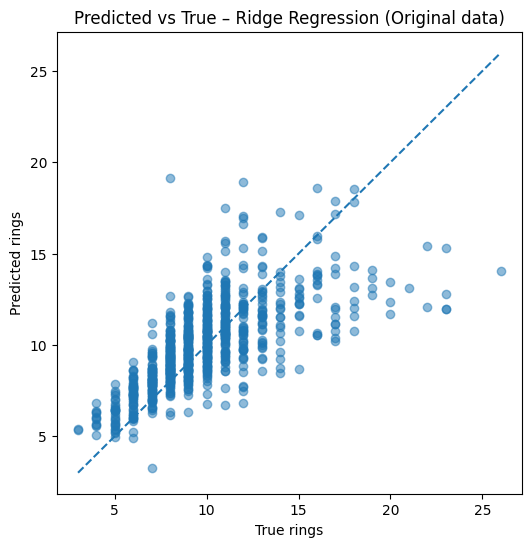

In [156]:
best_ridge = Ridge(alpha=1.0)   # <-- replace 1.0 with your best value, e.g. 0.01

best_ridge.fit(X_train_org, y_train_org)
y_pred = best_ridge.predict(X_test_org)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_org, y_pred, alpha=0.5)
plt.xlabel("True rings")
plt.ylabel("Predicted rings")
plt.title("Predicted vs True – Ridge Regression (Original data)")
plt.plot(
    [y_test_org.min(), y_test_org.max()],
    [y_test_org.min(), y_test_org.max()],
    linestyle="--"
)
plt.show()

### Analysis Summary of Ridge spread
| Observation                    | Meaning                                               |
| ------------------------------ | ----------------------------------------------------- |
| Points follow a diagonal trend | The model captures the general relationship           |
| Moderate vertical spread       | Prediction errors exist but not random                |
| Underestimation at high values | Model biased toward mean (Ridge regularization)       |
| Outliers present               | Some extreme values not well predicted                |
| Overall pattern                | Ridge captures trends but has limitations             |
| Compression of predictions     | Limited flexibility of linear model                   |

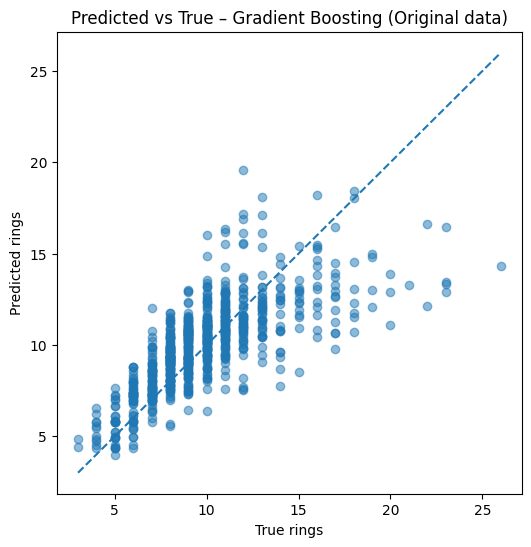

In [155]:
best_gbr = GradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=4,
    min_samples_leaf=5,
    n_estimators=100,
    random_state=42
)
best_gbr.fit(X_train_org, y_train_org)
y_pred = best_gbr.predict(X_test_org)

plt.figure(figsize=(6,6))
plt.scatter(y_test_org, y_pred, alpha=0.5)
plt.xlabel("True rings")
plt.ylabel("Predicted rings")
plt.title("Predicted vs True – Gradient Boosting (Original data)")
plt.plot([y_test_org.min(), y_test_org.max()],
         [y_test_org.min(), y_test_org.max()],
         linestyle="--")
plt.show()

### Summary of Gradient Boosting Regressor spread
The result is almost identical to Ridge, with only very slight improvements.
- It captures the nonlinear relationship between features and ring count.
- It still struggles slightly with very old specimens (rare values).
- The performance gain is visible both numerically (R², RMSE) and visually (closer to the diagonal).


## Final Considerations
Since my previous attempt at preprocessing the data didn't yield better results, I would consider:
- Trying different regression algorithms (e.g., Random Forest, XGBoost).
- Experimenting with ensemble methods (e.g., stacking, bagging).
- Revisiting feature engineering and selection to identify additional relevant features.

## Regrettable Notice
I would love to do further investigations and improvements on this notebook, but due to time constraints and other obligations, I regret to inform that I will not be able to continue working on this assignment.  
To be more spesific , I would have liked to:
- Explore additional models such as XGBoost or ensemble methods.
- Revisit feature engineering and selection to identify additional relevant features.
- Implement evaluation techniques which is listed in the `workshop0511.ipynb`.

These are points I'll definitely return to when time would deem it possible.